# Домашнее задание № 1 по курсу "ML для старта в Data Science"

В задании используется открытый датасет Wine Quality (Red Wine) – показатели химического состава португальского красного вина “Vinho Verde” и оценки его качества. Датасет содержит 1599 образцов красного вина и 12 признаков: 11 числовых физико-химических характеристик вина (кислотность, содержание сахара, pH, сульфиты и др.) и качество – итоговая оценка от 0 до 10 (целевой признак). Каждый экземпляр данных представляет одно вино, качество которого определено как медиана оценок нескольких экспертов (целое число от 0 до 10). 

Признаки (X):
- fixed acidity – фиксированная кислотность (г/дм³)
- volatile acidity – летучая кислотность (уксусная кислота, г/дм³)
- citric acid – лимонная кислота (г/дм³)
- residual sugar – остаточный сахар (г/дм³)
- chlorides – хлориды (соль, г/дм³)
- free sulfur dioxide – свободный диоксид серы (мг/дм³)
- total sulfur dioxide – общий диоксид серы (мг/дм³)
- density – плотность (г/см³)
- pH – кислотность (pH)
- sulphates – сульфаты (г/дм³)
- alcohol – содержание алкоголя (% об.)

Целевой признак:
- quality – оценка качества вина (целое число от 0 до 10)

*В этом задании мы закрепим навыки первых трёх тем:*
* предобработаем и проанализируем данные
* найдём и обработаем мультиколлинеарность
* попрактикуемся в работе с линейной регрессией
* разберёмся с проблемами переобучения
* применим регуляризацию для повышения качества и обобщающей способности модели

#### Критерии оценивания:

| Задание    | Балл |
| ---------- | ---- |
| Задание 1  | 15   |
| Задание 2  | 15   |
| Задание 3  | 15   |
| Задание 4  | 15   |
| Задание 5  | 20   |
| Задание 6  | 20   |

**Суммарно 100 баллов за задание.**

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# данные, предобработка, моделирование
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor

# метрики
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_log_error,
    max_error,
    r2_score
)

np.random.seed(28)

## Задание 1
Первым делом **познакомимся с данными**, а заодно закрепим методы работы с Pandas.

- Проверьте наличие пропусков в данных и при необходимости обработайте их.  
- Проверьте наличие выбросов и при необходимости почистите их.
- Проверьте наличие дубликатов и при необходимости почистите их.
- Подумайте, есть ли в данных неинформативные признаки, при необходимости удалите их.
- Запишите наблюдения в виде небольшого вывода.

In [65]:
# чтение данных
data = pd.read_csv('winequality-red.csv', header=0, sep=';')

print(data.shape)
data.head()# место для кода

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [66]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Несколько записей по поводу данных:
- 1599 образцов с 11 признаками и 1 таргетом в последнем столбце
- относительно большие отклонения от среднего и 75% квантиля имеются для: residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide (проверить на выбросы)

In [67]:
X = data.drop('quality', axis=1)
feature_names = X.columns

y = data['quality']

# X.head()
# y.head()

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
print(df.shape)
df.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [68]:
df.info() # info для проверки наличия пропусков в данных

# пропуски в данных не обнаружены, можно приступать к анализу

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  target                1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [69]:
# прверка дублей в данных
print(f"Количество дублей в данных по каждому столбцу: {df.duplicated().sum()}")

# демонстрация дублей в данных
print("Дубли в данных:")
print(df[df.duplicated()])

# дубли -- это строки, которые полностью идентичны друг другу. Они могут возникать по разным причинам, например, из-за ошибок при сборе данных или при объединении нескольких источников данных. Дубли могут искажать анализ данных и влиять на результаты моделей машинного обучения, поэтому важно их обнаружить и удалить.

# несмотря на то, что функция df.duplicated() показывает дубли 240, строки все отличаются друг от друга, так как в данных нет полностью идентичных строк. Поэтому можно сделать вывод, что дублей в данных нет. 

Количество дублей в данных по каждому столбцу: 240
Дубли в данных:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
4               7.4             0.700         0.00            1.90      0.076   
11              7.5             0.500         0.36            6.10      0.071   
27              7.9             0.430         0.21            1.60      0.106   
40              7.3             0.450         0.36            5.90      0.074   
65              7.2             0.725         0.05            4.65      0.086   
...             ...               ...          ...             ...        ...   
1563            7.2             0.695         0.13            2.00      0.076   
1564            7.2             0.695         0.13            2.00      0.076   
1567            7.2             0.695         0.13            2.00      0.076   
1581            6.2             0.560         0.09            1.70      0.053   
1596            6.3             0.510     

In [70]:
df.describe() # describe для получения статистики по данным, again ...

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Задание 2

Проведём небольшой **EDA.**

- Посмотрите на распределение целевого признака `quality` (`target`).
- Изучите распределения остальных признаков, а также парные зависимости (можете воспользоваться `pairplot` либо построить графики по отдельности).
- Постройте матрицу корреляций, визуализируйте её и проанализируйте наличие мультиколлинеарных признаков (в качестве порога можно взять ±0.7).
- Зафиксируйте наблюдения в небольшом выводе.

<Axes: >

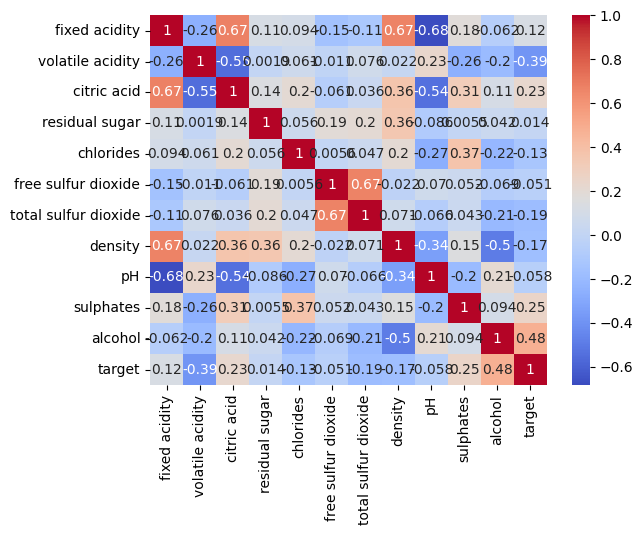

In [71]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

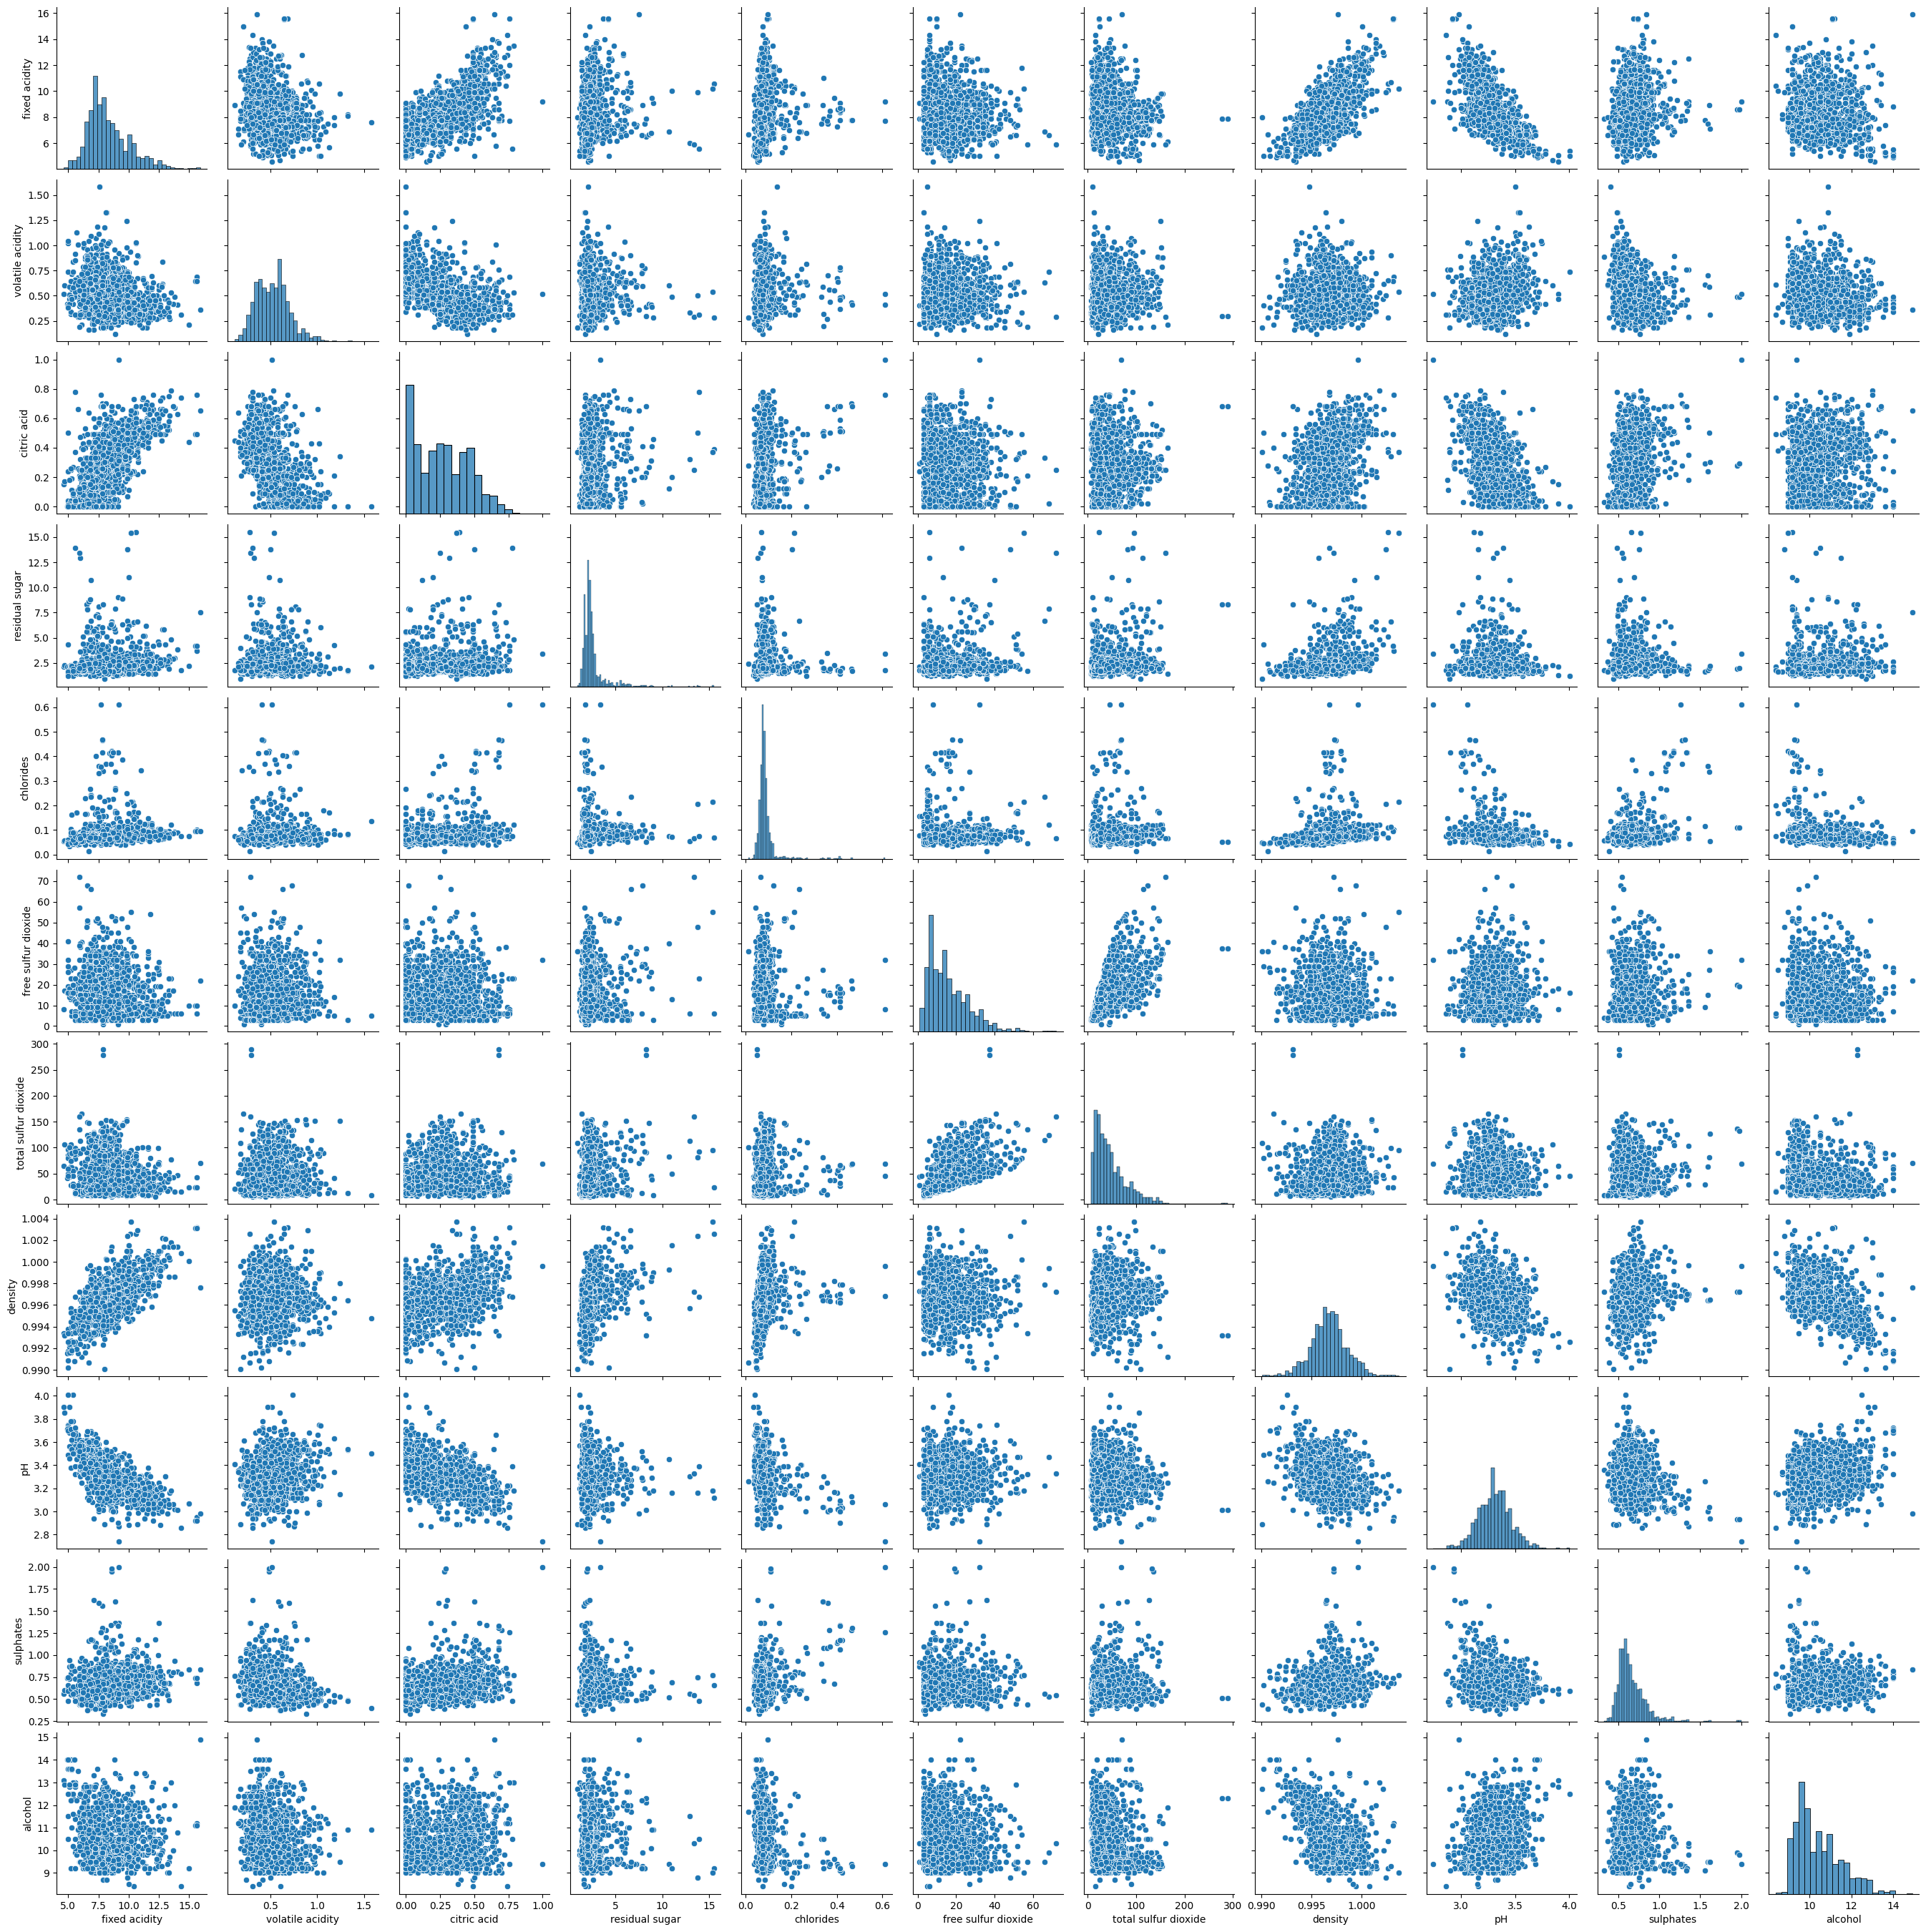

In [72]:
sns.pairplot(X) # для визуализации пар признаков и их распределения

Судя по графикАМ корреляции признаков, можно заметить следующие корреляции признаков (`около +-0.7 каждая созависимость, это относительно немного, но факторы, привлекшие наиб. внимание`), которые могут приводить к мультиколлинеарности:
- "free sulfur dioxide" и "total sulfur dioxide" имеют высокую положительную корреляцию, что может указывать на мультиколлинеарность между этими двумя признаками.
- "fixed acidity" и "citric acid" также имеют положительную корреляцию, что может указывать на мультиколлинеарность между этими признаками.
- "fixed acidity" и "pH" имеют отрицательную корреляцию, что может указывать на мультиколлинеарность между этими признаками.

Думаю, что стоит удалить один из признаков "free sulfur dioxide" и "total sulfur dioxide" (причем "free sulfur dioxide", так как на таргет он влияет в меньшей степени), так как они сильно коррелируют между собой (даже по смыслу - содержание диоксида серы общее и свободное ).
Также можно рассмотреть удаление одного из признаков "fixed acidity" и "citric acid", так как они также имеют высокую положительную корреляцию. fixed acidity определяет меньшую зависимость от качества вина, чем citric acid, так что я бы удалил fixed acidity.

In [73]:
X = X.drop(["free sulfur dioxide", "fixed acidity"], axis=1) # дропнул.
print(X)

feature_names = X.columns
y = df["target"]

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
print(df.shape)
df.head()

      volatile acidity  citric acid  residual sugar  chlorides  \
0                0.700         0.00             1.9      0.076   
1                0.880         0.00             2.6      0.098   
2                0.760         0.04             2.3      0.092   
3                0.280         0.56             1.9      0.075   
4                0.700         0.00             1.9      0.076   
...                ...          ...             ...        ...   
1594             0.600         0.08             2.0      0.090   
1595             0.550         0.10             2.2      0.062   
1596             0.510         0.13             2.3      0.076   
1597             0.645         0.12             2.0      0.075   
1598             0.310         0.47             3.6      0.067   

      total sulfur dioxide  density    pH  sulphates  alcohol  
0                     34.0  0.99780  3.51       0.56      9.4  
1                     67.0  0.99680  3.20       0.68      9.8  
2              

,volatile acidity,citric acid,residual sugar,chlorides,total sulfur dioxide,density,pH,sulphates,alcohol,target
0,0.70,0.00,1.9,0.076,34.0,0.9978,3.51,0.56,9.4,5
1,0.88,0.00,2.6,0.098,67.0,0.9968,3.20,0.68,9.8,5
2,0.76,0.04,2.3,0.092,54.0,0.9970,3.26,0.65,9.8,5
3,0.28,0.56,1.9,0.075,60.0,0.9980,3.16,0.58,9.8,6
4,0.70,0.00,1.9,0.076,34.0,0.9978,3.51,0.56,9.4,5


<Axes: >

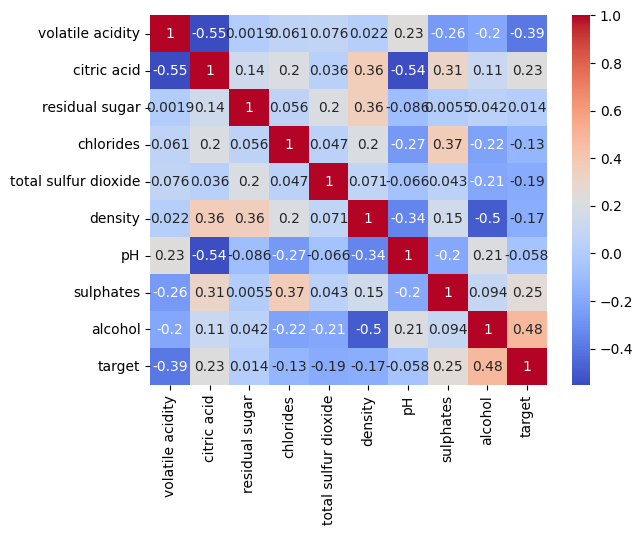

In [74]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')


Наибольший вклад в качество вина вносили следующие признаки: alcohol, volatile acidity, sulphates, citric acid.
Они имеют наибольшую абсолютную корреляцию с целевой переменной "quality".

Хотя, это лишь прикидочные суждения, так как комбинации признаков могут влиять на качество вина, и их взаимодействия могут быть сложными.

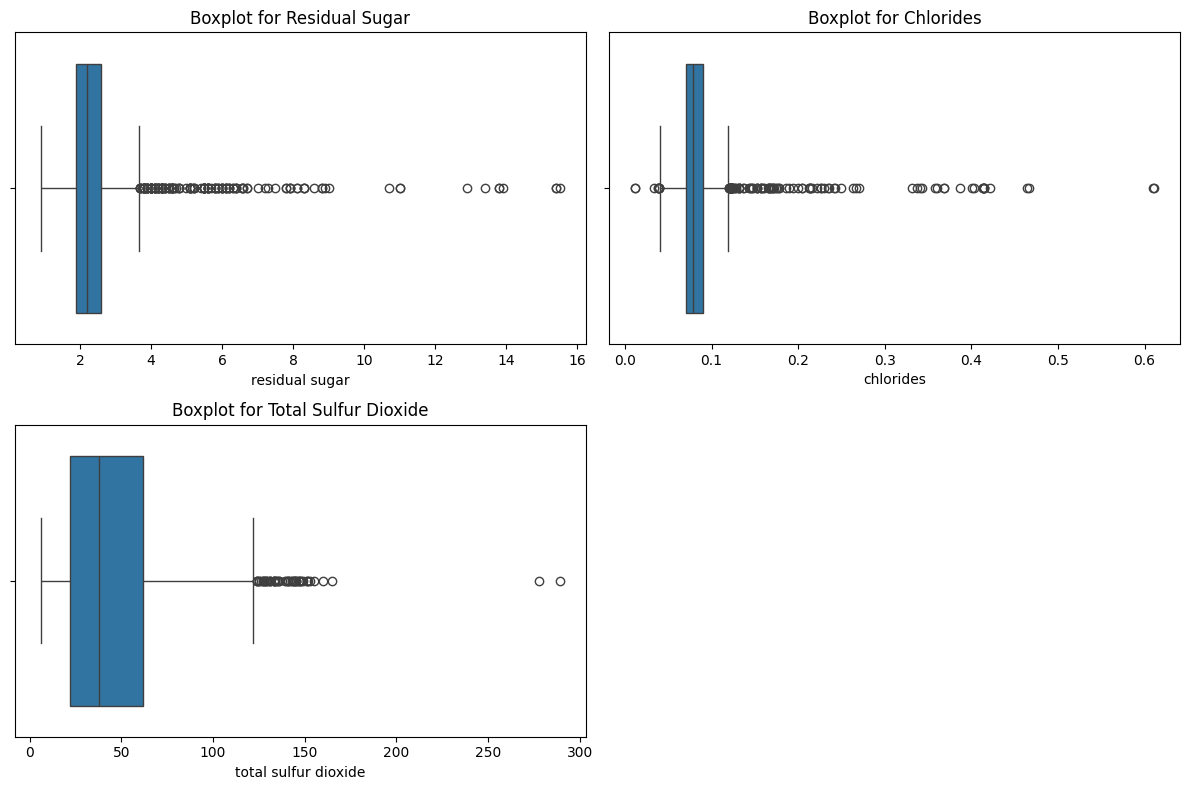

In [75]:
# проверка того, что я предположил как "возможные выбросы" (residual sugar, chlorides, total sulfur dioxide):
# free sulfur dioxide уже был удалён из df выше, поэтому строим 3 boxplots

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.boxplot(x=df["residual sugar"])
plt.title("Boxplot for Residual Sugar")
plt.subplot(2, 2, 2)
sns.boxplot(x=df["chlorides"])
plt.title("Boxplot for Chlorides")
plt.subplot(2, 2, 3)
sns.boxplot(x=df["total sulfur dioxide"])
plt.title("Boxplot for Total Sulfur Dioxide")
plt.tight_layout()
plt.show()

# все три признака имеют правостороннюю скошенность, что может указывать на наличие выбросов. Но их множество, они не единичны и вполне вероятно, что они не являются аномалиями, поэтому удалять их не стоит.

In [76]:
# просто ради практики дропну 2 точки в признаке "total sulfur dioxide", так как там явно видны 2 выброса, которые сильно отличаются от остальных данных.

# При этом я не заявляю, что это необходимо. Ради инетереса :)

print(df['total sulfur dioxide'].sort_values(ascending=False).head(10))

1081    289.0
1079    278.0
354     165.0
1244    160.0
651     155.0
109     153.0
684     152.0
515     151.0
672     151.0
591     149.0
Name: total sulfur dioxide, dtype: float64


In [77]:
df = df[df['total sulfur dioxide'] < 278]
# other way more elegant

print(df['total sulfur dioxide'].sort_values(ascending=False).head(10))

354     165.0
1244    160.0
651     155.0
109     153.0
684     152.0
672     151.0
515     151.0
591     149.0
15      148.0
649     148.0
Name: total sulfur dioxide, dtype: float64


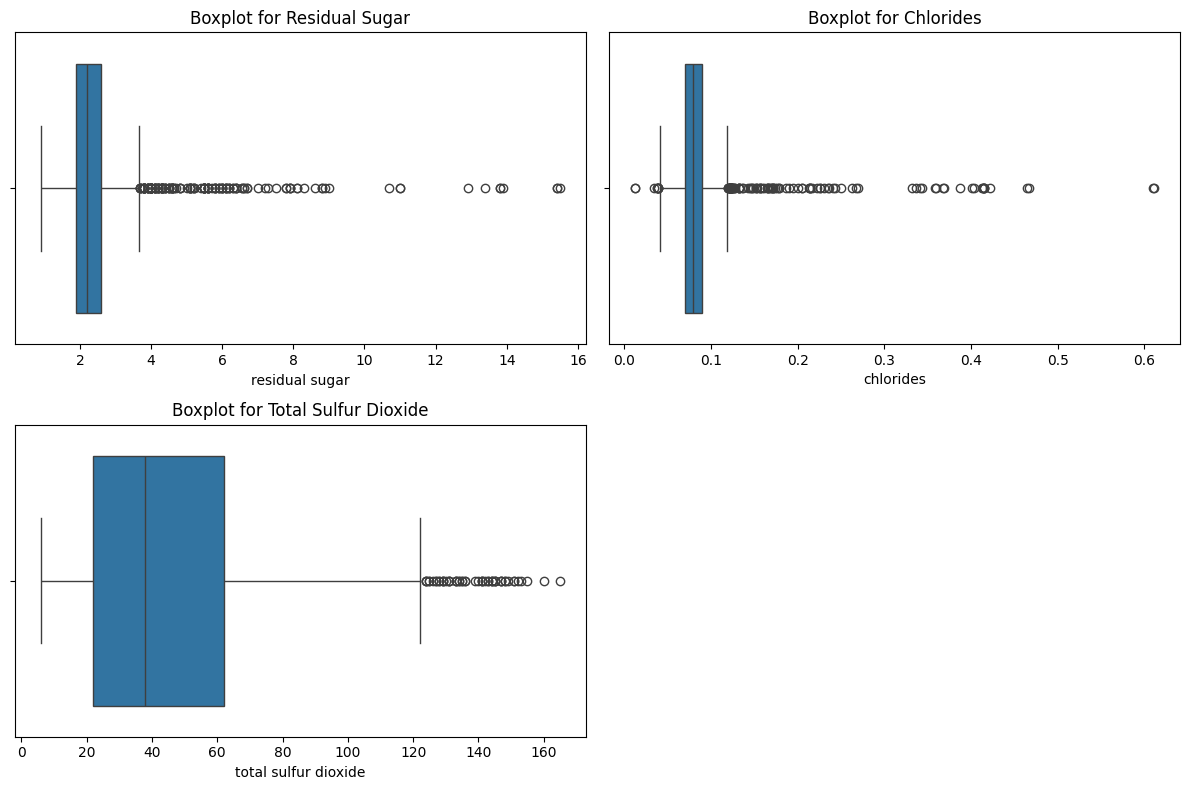

In [78]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.boxplot(x=df["residual sugar"])
plt.title("Boxplot for Residual Sugar")
plt.subplot(2, 2, 2)
sns.boxplot(x=df["chlorides"])
plt.title("Boxplot for Chlorides")
plt.subplot(2, 2, 3)
sns.boxplot(x=df["total sulfur dioxide"])
plt.title("Boxplot for Total Sulfur Dioxide")
plt.tight_layout()
plt.show()

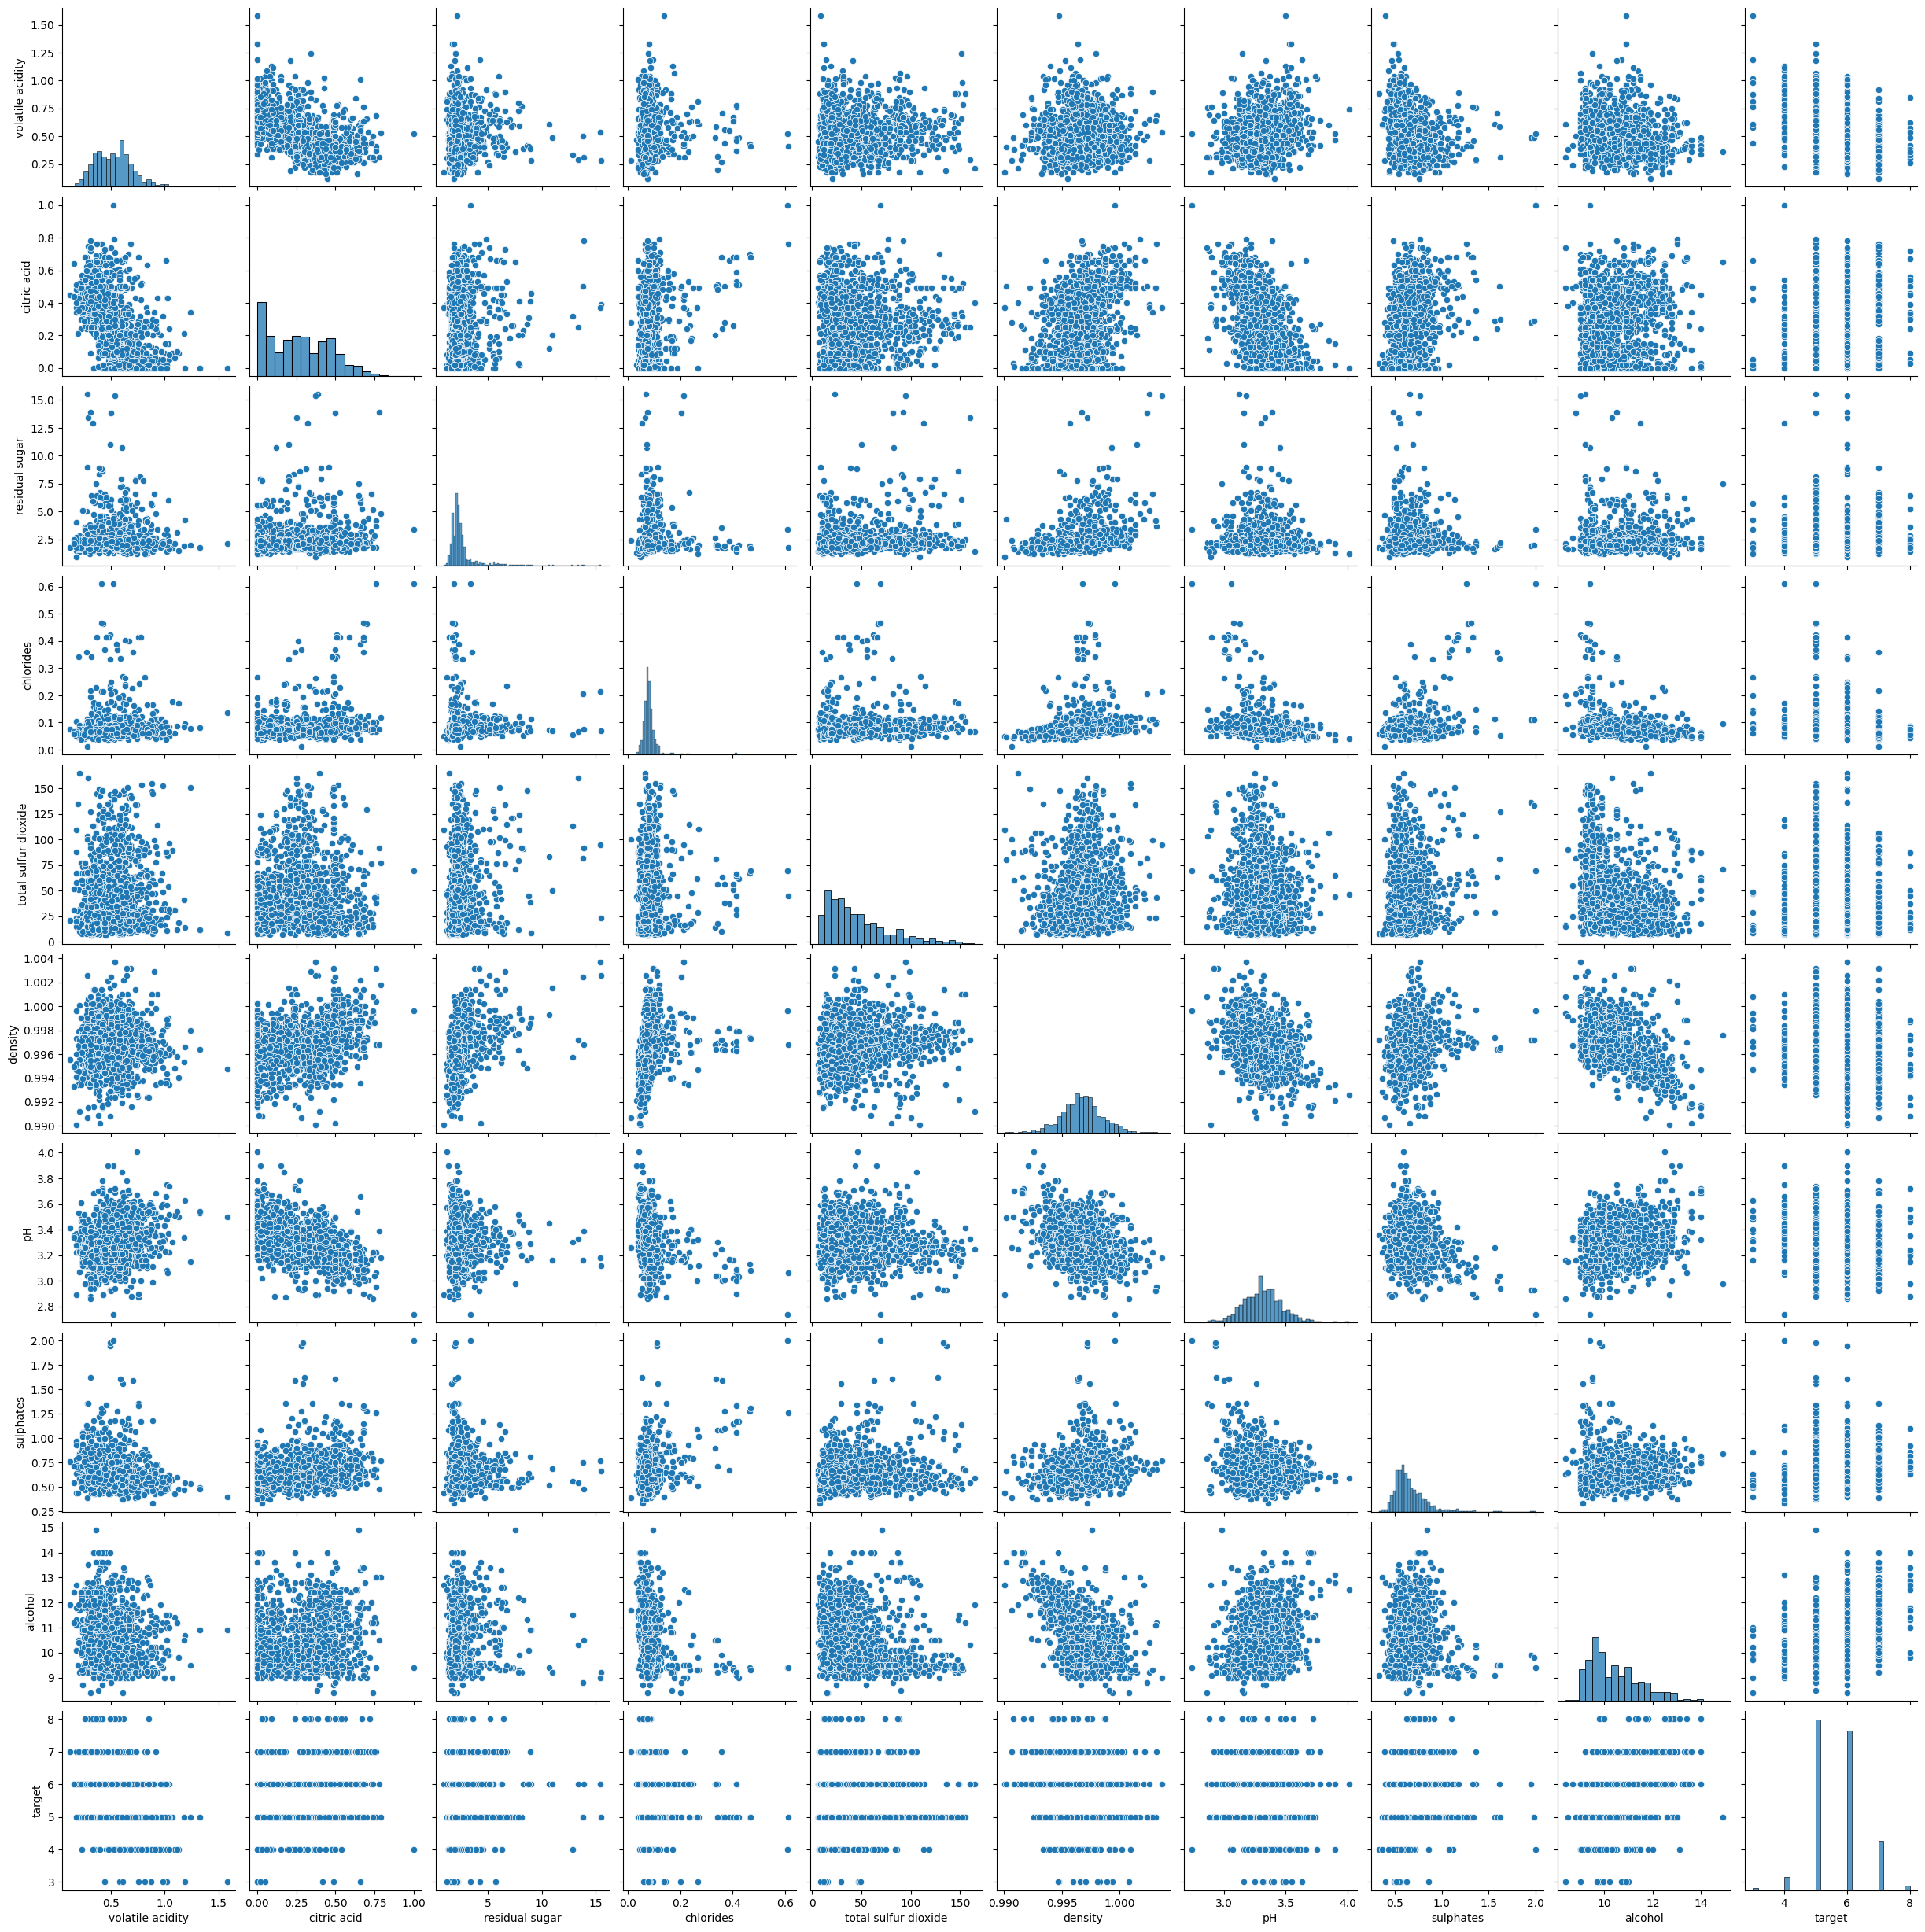

In [79]:
sns.pairplot(df) # для визуализации пар признаков и их распределения

## Мини-отчет сразу по заданиям 1 и 2

- пропусков не оказалось.

- обнаружил несколько выбросов, которые решил зачистить. Хотя теоретически это не были ошибочные данные и возможно этого не стоило делать. Надо смотреть, возможно ли, чтобы реальное содержание серы было 270+ у.е., вполне вероятно, но я удалил для практики :)

- с пом. sns.heatmap() и sns.pairplot(X) проверил, как коррелируют признаки между собой. Выявил несколько факторов (2 из 11), которые показались наиболее коррелирующими с другими двумя. Опять же, надо смотреть реальную взаимосвязь (как например, "free sulfur dioxide" и "total sulfur dioxide", где она абсолютно очевидна. Такие же связи есть между данными кислотности pH и содержанием кислоты в других у.е.)... удалил пару сразу.

- ориентировочно на качество вина положительно влияют больше всего (ориентировочно, если судить по отдельности, не в комбинации с другими факторами): alcohol, sulphates, citric acid. негативно -- volatile acidity.

## Задание 3

**Финально подготовим данные для модели.**

* По итогам EDA удалите сильно скоррелированные признакие, если они нашлись; а также выбросы/ошибочные записи - всё, что посчитаете нужным.
* Создайте матрицу признаков `X` и вектор таргета `y`, *не забудьте добавить столбец "свободных членов" из единиц в матрицу `X`, чтобы использовать её в собственноручно написанных алгоритмов*.
* Разбейте данные на тренировочную и тестовую выборку, установите соотношение 80/20 и random_state=42.
* Выберите подходящий способ масштабирования или нормализации данных; примените его для датасета - не забудьте, что на тестовой выборке необходимо выполнить только трансформирование.
* Зафиксируйте выполненные преобразования в текстовом виде в конце.

In [80]:
# Разделим на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # method from sklearn, test_size=0.2 -- 20% данных отводим на тест, random_state=42 -- для воспроизводимости результатов

print(X_train.shape, X_test.shape)

# Стандартизируем данные
scaler = StandardScaler() # StandardScaler -- это класс из библиотеки sklearn, который используется для стандартизации обучающих данных. Он удаляет среднее и масштабирует данные до единичной дисперсии, что помогает улучшить производительность многих алгоритмов машинного обучения, особенно тех, которые чувствительны к масштабу данных.
X_train = scaler.fit_transform(X_train) # fit_transform -- это метод, который сначала вычисляет среднее и стандартное отклонение для каждого признака в обучающем наборе данных (fit), а затем применяет эти параметры для стандартизации данных (transform). Это гарантирует, что стандартизация выполняется на основе статистики обучающего набора данных, что важно для предотвращения утечки данных из тестового набора.
print('X_train:', X_train, '\n')
X_test = scaler.transform(X_test) # only transform -- это метод, который применяет стандартизацию к тестовому набору данных, используя параметры (среднее и стандартное отклонение), вычисленные на обучающем наборе данных. Это важно для обеспечения того, чтобы тестовые данные были стандартизированы в том же масштабе, что и обучающие данные, без использования информации из тестового набора.
print('X_test:', X_test)

# Добавим признак-смещение (bias)
X_train = np.c_[np.ones(X_train.shape[0]), X_train] # np.c_ -- это функция из библиотеки NumPy, которая используется для объединения массивов по столбцам. В данном случае она добавляет столбец единиц (bias) в начало массива X_train. Это необходимо для того, чтобы модель линейной регрессии могла учитывать свободный член (intercept) при обучении.
print('X_train with bias:', X_train, '\n')
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

(1279, 9) (320, 9)
X_train: [[ 0.88971201  0.19209222  0.30972563 ...  1.09349989  0.45822284
   1.12317723]
 [-1.78878251  0.65275338 -0.80507963 ... -0.40043872 -0.40119696
   1.40827174]
 [-0.78434707  1.01104539 -0.52637831 ... -0.07566946  0.51551749
  -0.58738978]
 ...
 [ 0.49909822 -1.08752211  0.10069964 ...  1.28836145 -0.68767023
  -0.87248428]
 [-1.84458448  0.39683051 -0.59605364 ...  0.05423824  0.80199076
   1.40827174]
 [-1.34236676 -0.06383064 -0.59605364 ...  0.50891521 -0.68767023
   2.92877575]] 

X_test: [[ 1.64286407e-01 -9.85152962e-01 -3.86510130e-02 ... -4.65392578e-01
  -1.34389336e-04 -7.77452782e-01]
 [-1.70525408e-01 -5.24491803e-01 -6.65728970e-01 ...  5.08915214e-01
  -1.03143815e+00 -8.72484283e-01]
 [ 7.78108067e-01 -2.68568937e-01  1.00699644e-01 ... -2.05577167e-01
   1.83329452e+00 -4.92358280e-01]
 ...
 [ 3.87494284e-01 -1.15015218e-01 -2.47676999e-01 ... -1.04997725e+00
  -7.44964886e-01 -5.87389780e-01]
 [-1.45397070e+00  6.01568807e-01 -3.87027656

## Порядок выполнения был такой (после предобработки): 

1. разделение данных на обучающую и тестовую выборки (в соотношении 80 обуч на 20 тест)
2. стандартизация данных (стандартизуем по обучающему набору данных, а тестовый набор стандартизуем на основе параметров обучающего набора данных). Это важно для предотвращения утечки данных из тестового набора и обеспечения того, чтобы тестовые данные были стандартизированы в том же масштабе, что и обучающие данные.
3. добавление признака-смещения (bias) для модели линейной регрессии

## Задание 4

**Приступаем к моделированию!**

* Первым делом предлагаем построить модель линейной регрессии по МНК: попробуйте воспользоваться ручной реализацией и сравнить результат с `LinearRegression` из `sklearn`.
* Оцените модель по метрикам MSE, MAE и MAPE на тренировочной и тестовой выборках. Проанализируйте полученные метрики - насколько модель хорошо предсказывает результат?
* Напишите небольшой вывод касательно полученных результатов.

In [81]:
# ручные функции для обучения модели линейной регрессии с пом. МНК и расчета метрик

def predict(X, weights):
    """
    Расчёт предсказания модели
    """
    return X @ weights

def mse_loss(y_true, y_pred):
    """
    Расчёт значения функции ошибки MSE
    """
    return np.mean((y_true - y_pred) ** 2)

def plot_history(losses):
    """
    Визуализация графика сходимости
    (значение loss в зависимости от номера итерации)
    """
    plt.plot(losses)
    plt.xlabel("Iteration")
    plt.ylabel("MSE Loss")
    plt.title("График сходимости градиентного спуска")
    plt.grid(True)
    plt.show()

def regression_metrics(y_true, y_pred):
    """
    Вычисляет метрики качества линейной регрессии.

    Parameters
    ----------
    y_true : array-like
        Реальные значения (таргет).
    y_pred : array-like
        Предсказанные значения.

    Returns
    -------
    dict
        Словарь с метриками: MSE, RMSE, MAE, MAPE, MSLE, MaxError, R².
    """

    # MSE
    mse = mean_squared_error(y_true, y_pred)

    # RMSE
    rmse = np.sqrt(mse)

    # MAE
    mae = mean_absolute_error(y_true, y_pred)

    # MAPE (может вернуть inf, если y_true содержит нули)
    try:
        mape = mean_absolute_percentage_error(y_true, y_pred)
    except:
        mape = np.nan

    # MSLE (работает только если y_true, y_pred >= 0)
    try:
        msle = mean_squared_log_error(y_true, y_pred)
    except:
        msle = np.nan

    # MaxError
    max_err = max_error(y_true, y_pred)

    # R^2
    r2 = r2_score(y_true, y_pred)

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "MSLE": msle,
        "MaxError": max_err,
        "R²": r2
    }

## Метод наименьших квадратов (OLS).

*Базовая формула:*

$w=(X^TX)^{−1}X^Ty$

In [82]:
def least_squares(X, y):
    """
    Решение задачи линейной регрессии методом МНК (OLS).

    X : np.ndarray, shape (n_samples, n_features)
        Матрица признаков (с уже добавленным столбцом единиц, если нужен bias).
    y : np.ndarray, shape (n_samples,)
        Вектор целевой переменной.

    return:
        weights : np.ndarray, shape (n_features,)
            Вектор весов линейной регрессии.
    """
    xtx_inv = np.linalg.inv(X.T @ X)
    weights = xtx_inv @ X.T @ y
    return weights

In [83]:
# реализация вручную
weights_my_lsm = least_squares(X_train, y_train)
print(weights_my_lsm) # веса

# считаем предсказания на train и test
p_my_lsm_train = predict(X_train, weights_my_lsm)
p_my_lsm_test = predict(X_test, weights_my_lsm)

[ 5.62392494 -0.18744058 -0.02902552  0.00623384 -0.09098228 -0.08388869
  0.0081639  -0.07531783  0.14630078  0.31221963]


In [84]:
# вручную реализованный МНК
display(regression_metrics(y_train, p_my_lsm_train))
print()
display(regression_metrics(y_test, p_my_lsm_test))

{'MSE': 0.42628749308000236,
 'RMSE': np.float64(0.6529069559133234),
 'MAE': 0.5025781557533316,
 'MAPE': 0.09254541917162974,
 'MSLE': 0.010205674665079083,
 'MaxError': 2.5716510645067387,
 'R²': 0.34477042490553667}

{'MSE': 0.388381975222004,
 'RMSE': np.float64(0.623202996801206),
 'MAE': 0.5035805254763568,
 'MAPE': 0.08990879367565796,
 'MSLE': 0.008874512757758666,
 'MaxError': 2.2416684271548855,
 'R²': 0.40569473150027335}

Выводы по метрикам: MSE, RMSE, MAE, MAPE, MSLE, MaxError, R² для обучающего и тестового наборов данных показывают, что модель линейной регрессии, обученная методом МНК, имеет определённую степень точности в предсказании целевой переменной.
Точнее, MSE и RMSE для тестового набора данных выше, чем для обучающего, что может указывать на некоторое переобучение модели. MAE также выше на тестовом наборе, что подтверждает это наблюдение. MAPE и MSLE могут быть неинформативными из-за возможных нулевых значений в y_true, что может привести к бесконечности или NaN. MaxError показывает максимальную ошибку между предсказанными и реальными значениями, и она также выше на тестовом наборе. R² для тестового набора ниже, чем для обучающего, что указывает на то, что модель объясняет меньше вариации в данных тестового набора по сравнению с обучающим набором. В целом, эти метрики указывают на то, что модель может быть переобученной и не обобщается хорошо на новые данные.

--------

Как оценивать по MSE?

MSE (Mean Squared Error) -- это среднеквадратичная ошибка, которая измеряет среднюю квадратичную разницу между предсказанными и реальными значениями. Чем ниже значение MSE, тем лучше модель.

Relative error (относительная ошибка) -- это метрика, которая измеряет ошибку модели относительно истинных значений. Она может быть выражена в процентах и позволяет понять, насколько предсказания модели отличаются от реальных данных в относительном выражении. Чем ниже относительная ошибка, тем лучше модель.

From MSE to Relative Error: A Guide to Evaluating Model Performance: formula:

Relative Error = |(y_true - y_pred) / y_true| * 100%

-------

R² -- это коэффициент детерминации, который измеряет, насколько хорошо модель объясняет вариацию в данных. Он принимает значения от 0 до 1, где 1 означает, что модель идеально объясняет все вариации в данных, а 0 означает, что модель не объясняет вариацию вообще. R² может быть отрицательным, если модель хуже, чем простое среднее значение целевой переменной. В данном случае, более высокое значение R² для обучающего набора по сравнению с тестовым набором может указывать на переобучение модели.

In [85]:
# relative error
relative_error = np.abs(p_my_lsm_train - y_train) / np.abs(y_train) * 100
print("Mean Relative Error (train data):", relative_error.mean(), '%')

relative_error = np.abs(p_my_lsm_test - y_test) / np.abs(y_test) * 100
print("Mean Relative Error (test data):", relative_error.mean(), '%')

Mean Relative Error (train data): 9.254541917162975 %
Mean Relative Error (test data): 8.990879367565796 %


In [86]:
# встроенная реализация в sklearn
model_skl_lsm = LinearRegression(fit_intercept=False)
model_skl_lsm.fit(X_train, y_train)
print(model_skl_lsm.coef_) # веса

# считаем предсказания на train и test
p_skl_lsm_train = model_skl_lsm.predict(X_train)
p_skl_lsm_test = model_skl_lsm.predict(X_test)

[ 5.62392494 -0.18744058 -0.02902552  0.00623384 -0.09098228 -0.08388869
  0.0081639  -0.07531783  0.14630078  0.31221963]


In [87]:
# МНК из sklearn
display(regression_metrics(y_train, p_skl_lsm_train))
print()
display(regression_metrics(y_test, p_skl_lsm_test))

# relative error
relative_error = np.abs(p_skl_lsm_train - y_train) / np.abs(y_train) * 100
print("Mean Relative Error (train data):", relative_error.mean(), '%')

relative_error = np.abs(p_skl_lsm_test - y_test) / np.abs(y_test) * 100
print("Mean Relative Error (test data):", relative_error.mean(), '%')

{'MSE': 0.42628749308000236,
 'RMSE': np.float64(0.6529069559133234),
 'MAE': 0.5025781557533309,
 'MAPE': 0.09254541917162942,
 'MSLE': 0.01020567466507907,
 'MaxError': 2.571651064506728,
 'R²': 0.34477042490553667}

{'MSE': 0.3883819752220046,
 'RMSE': np.float64(0.6232029968012065),
 'MAE': 0.5035805254763561,
 'MAPE': 0.08990879367565766,
 'MSLE': 0.008874512757758666,
 'MaxError': 2.2416684271548757,
 'R²': 0.40569473150027247}

Mean Relative Error (train data): 9.254541917162943 %
Mean Relative Error (test data): 8.990879367565764 %


## ВЫВОДЫ по заданию 4. МНК.

- OLS очень вероятно подарил нам `переобучение`, ведь относительные ошибки "натягивания" весов дали большую ошибку на тренировочных (обучающих) данных, нежели чем на тестовых, полученных как раз из тренировки.

Возможно, метод МНК не оч пригоден, или коллинеарности признаков сохранились и надо выбросить еще несколько факторов.

P.S. Попробовал выкинуть еще factor `citric acid` -> всё равно примерно то же самое ~9% ошибка относительная предсказаний, причем всё равно на тренировке больше ошибка, чем на тесте.

## Задание 5

**Попробуем усложнить.**

* Выберите не менее 3-х вариаций градиентного спуска и обучите их на имеющихся данных. Интересно "поиграться" с гиперпараметрами шага, количества итераций и т.п. Попробуйте получить как можно более высокое качество алгоритма.
* Постройте для каждого эксперимента график сходимости и также оцените модель по метрикам MSE, MAE и MAPE.
* Напишите небольшой вывод - удалось ли улучшить прогноз?

In [88]:
# место для кода

In [89]:
# место для кода

In [90]:
# место для Вашего прекрасного кода

<место для интересных выводов и рассуждений!>

## Задание 6

А что, если бы мы не стали удалять никакие признаки, а просто сразу применили бы **регуляризацию**? Попробуйте в рамках этого задания:
* Взять данные без удаления мультиколлинеарных признаков и обучить на них лучший алгоритм, который Вам удалось выявить в предыдущих заданиях, *без регуляризации*. Посмотрите, как ведут себя метрики на тренировочном и тестовом наборе, а также какие веса у модели.
* Взять данные без удаления мультиколлинеарных признаков и обучить на них лучший алгоритм, который Вам удалось выявить в предыдущих заданиях, *с L1 и L2 регуляризацией* по отдельности. Сравните метрики и веса с прошлым вариантом, а также с полученными результатами в 4-5 заданиях.
* Что лучше: обучиться на всех данных с регуляризацией или превентивно устранять мультиколлинеарность? Для самой наилучшей модели определите, какие признаки наиболее важны при прогнозировании. Отразите итоговые рекомендации в выводе.

In [91]:
# место для кода

In [92]:
# место для кода

In [93]:
# место для кода

<место для интересных выводов и рассуждений!>

## 🎉 Всё получилось?
Когда решите, что сделали всё возможное - присылайте задание нам на проверку 😊

Достаточно будет ссылки на colab-ноутбук, **самое главное - проверьте, что открыли доступ к файлу!**
